In [1]:
import pandas as pd
import numpy as np
import os

X_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_train.parquet"
)

X_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_test.parquet"
)

y_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_train.parquet"
)["Label"]

y_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_test.parquet"
)["Label"]

label_mapping = pd.read_csv(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/label_mapping.csv"
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1785379, 77)
X_test : (446345, 77)
y_train: (1785379,)
y_test : (446345,)


# Correlation Analysis

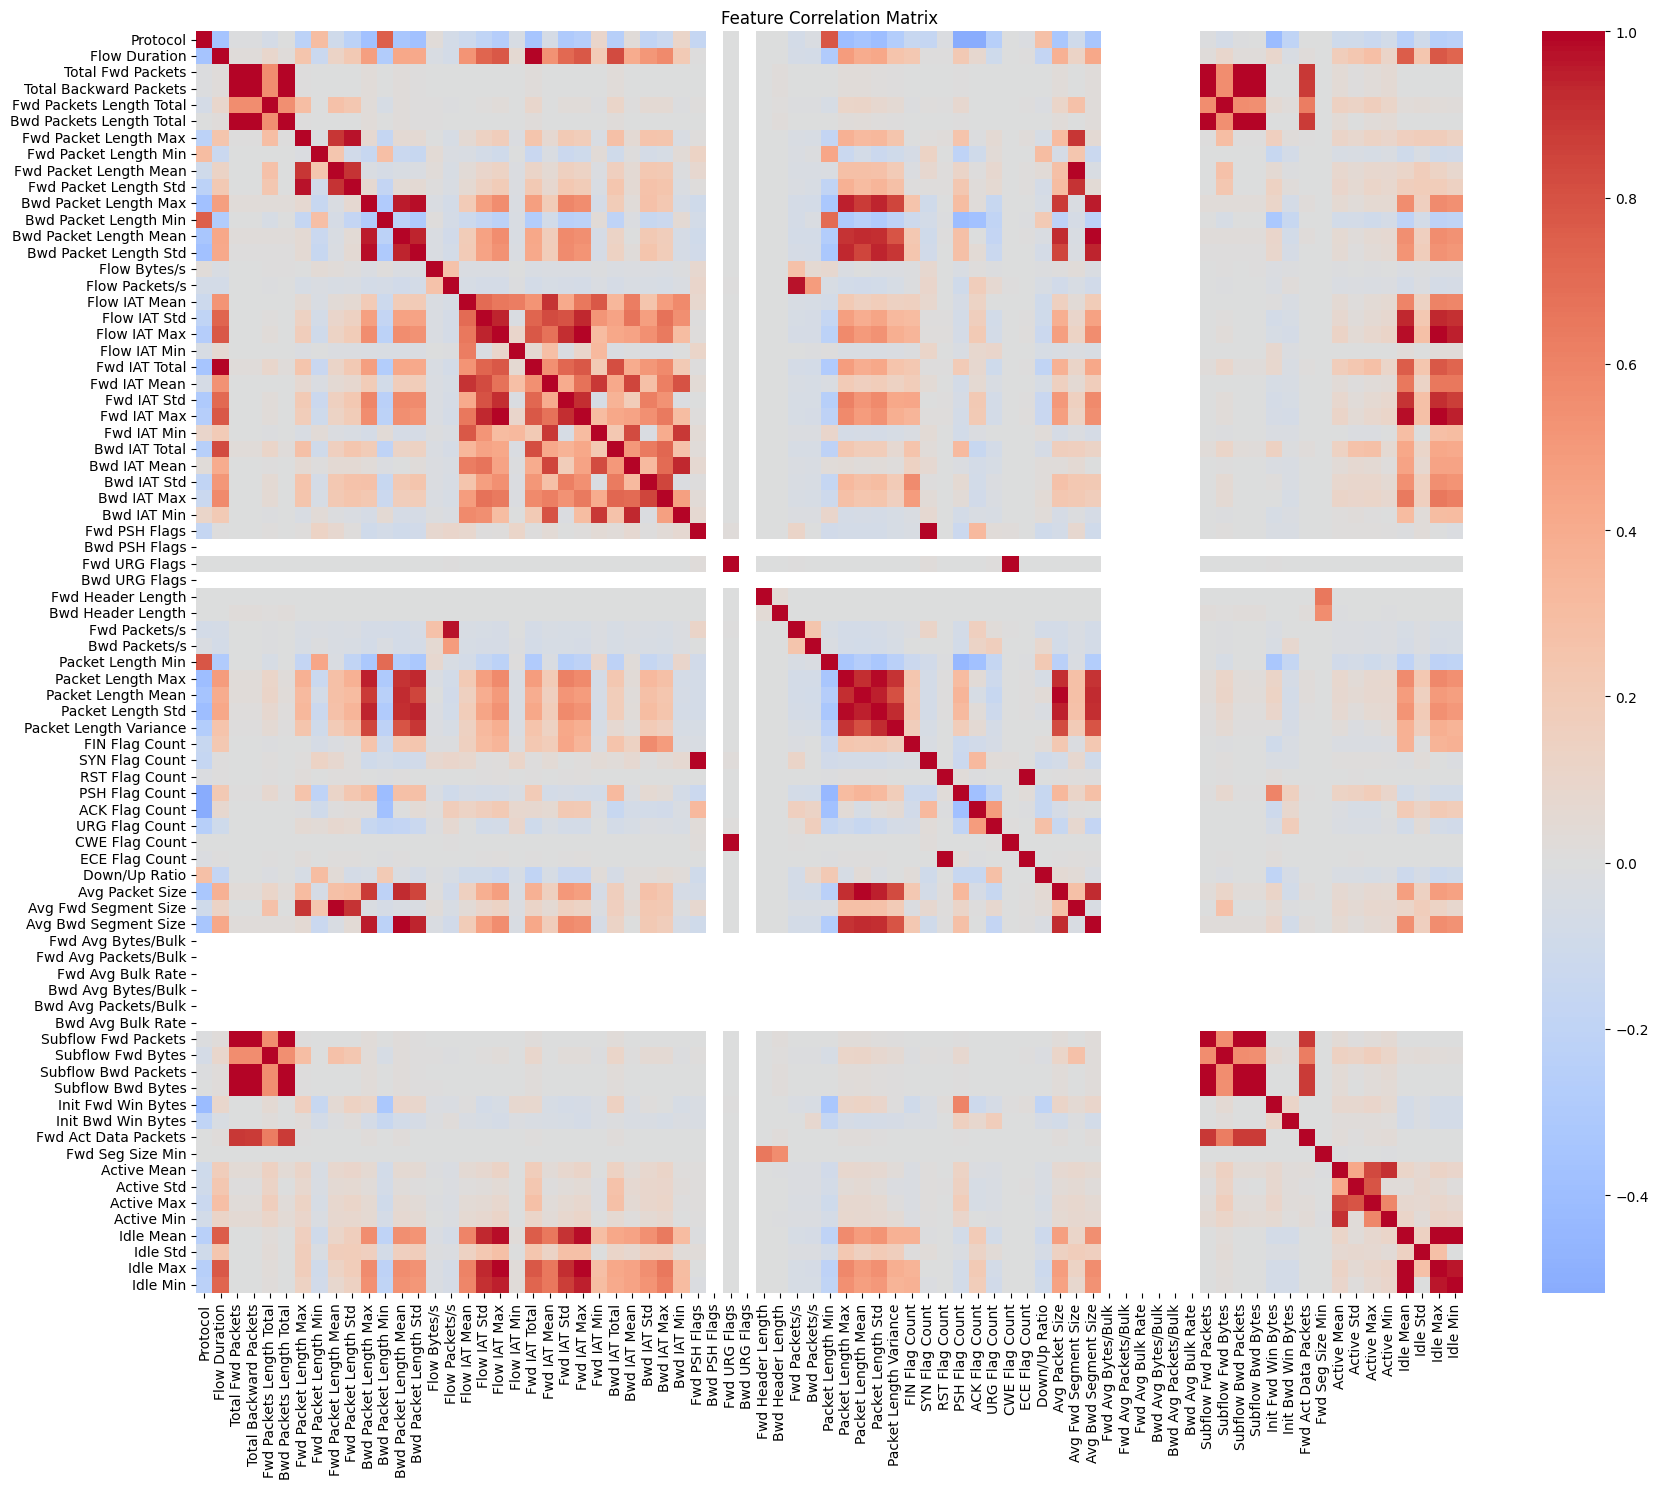

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = X_train.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [3]:
correlation_threshold = 0.95

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(
        abs(upper_triangle[column]) > correlation_threshold
    )
]

print("Number of highly correlated features:",
      len(high_corr_features))

print("\nFeatures marked for removal:")
print(high_corr_features)

Number of highly correlated features: 22

Features marked for removal:
['Total Backward Packets', 'Bwd Packets Length Total', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']


In [4]:
X_train_corr = X_train.drop(
    columns=high_corr_features
)

X_test_corr = X_test.drop(
    columns=high_corr_features
)

print("Original features :", X_train.shape[1])
print("After correlation :", X_train_corr.shape[1])

Original features : 77
After correlation : 55


### Creating a representative training sample : 
This prevents Boruta/SHAP from having to process all 1.78 million rows.

In [5]:
train_for_selection = X_train_corr.copy()
train_for_selection["Label"] = y_train.values

samples = []

for label, group in train_for_selection.groupby("Label"):

    n = min(5000, len(group))

    samples.append(
        group.sample(
            n=n,
            random_state=42
        )
    )

selection_data = pd.concat(
    samples,
    ignore_index=True
)

selection_data = selection_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_selection = selection_data.drop(
    columns=["Label"]
)

y_selection = selection_data["Label"]

print("Selection sample:", X_selection.shape)
print("\nClass distribution:")
print(y_selection.value_counts().sort_index())

Selection sample: (40277, 55)

Class distribution:
Label
0     5000
1     1149
2     5000
3     5000
4     5000
5     4182
6     4308
7     4745
8        9
9       29
10    1565
11    2575
12    1176
13      17
14     522
Name: count, dtype: int64


In [6]:
# Save the 55 correlation-selected features

X_train_corr.to_parquet(
    "/kaggle/working/X_train_correlation_55.parquet"
)

X_test_corr.to_parquet(
    "/kaggle/working/X_test_correlation_55.parquet"
)

# Save the feature names as well
pd.DataFrame({
    "Feature": X_train_corr.columns
}).to_csv(
    "/kaggle/working/correlation_55_features.csv",
    index=False
)

print("55-feature datasets saved successfully!")
print("X_train_corr:", X_train_corr.shape)
print("X_test_corr:", X_test_corr.shape)
print("Number of features:", len(X_train_corr.columns))

55-feature datasets saved successfully!
X_train_corr: (1785379, 55)
X_test_corr: (446345, 55)
Number of features: 55


In [7]:
!pip install -q boruta

In [8]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Boruta

In [9]:
boruta_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

boruta_selector = BorutaPy(
    estimator=boruta_rf,
    n_estimators="auto",
    max_iter=30,
    random_state=42,
    verbose=2
)

boruta_selector.fit(
    X_selection.values,
    y_selection.values
)

Iteration: 	1 / 30
Confirmed: 	0
Tentative: 	55
Rejected: 	0
Iteration: 	2 / 30
Confirmed: 	0
Tentative: 	55
Rejected: 	0
Iteration: 	3 / 30
Confirmed: 	0
Tentative: 	55
Rejected: 	0
Iteration: 	4 / 30
Confirmed: 	0
Tentative: 	55
Rejected: 	0
Iteration: 	5 / 30
Confirmed: 	0
Tentative: 	55
Rejected: 	0
Iteration: 	6 / 30
Confirmed: 	0
Tentative: 	55
Rejected: 	0
Iteration: 	7 / 30
Confirmed: 	0
Tentative: 	55
Rejected: 	0
Iteration: 	8 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	9 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	10 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	11 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	12 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	13 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	14 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	15 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteration: 	16 / 30
Confirmed: 	43
Tentative: 	2
Rejected: 	10
Iteratio

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                          max_depth=10, n_estimators=94,
                                          n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x7D933AFE6D40),
         max_iter=30, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D933AFE6D40, verbose=2)

In [10]:
boruta_results = pd.DataFrame({
    "Feature": X_selection.columns,
    "Boruta_Rank": boruta_selector.ranking_,
    "Boruta_Support": boruta_selector.support_,
    "Boruta_Tentative": boruta_selector.support_weak_
})

boruta_results = boruta_results.sort_values(
    by=["Boruta_Rank", "Feature"]
)

boruta_results.to_csv(
    "/kaggle/working/boruta_results.csv",
    index=False
)

print(boruta_results.head(20))

                  Feature  Boruta_Rank  Boruta_Support  Boruta_Tentative
37         ACK Flag Count            1            True             False
52             Active Max            1            True             False
50            Active Mean            1            True             False
53             Active Min            1            True             False
28      Bwd Header Length            1            True             False
21            Bwd IAT Max            1            True             False
19           Bwd IAT Mean            1            True             False
22            Bwd IAT Min            1            True             False
20            Bwd IAT Std            1            True             False
18          Bwd IAT Total            1            True             False
7   Bwd Packet Length Max            1            True             False
8   Bwd Packet Length Min            1            True             False
29          Bwd Packets/s            1            T

In [11]:
boruta_features = X_selection.columns[
    boruta_selector.support_
].tolist()

print(
    "Number of Boruta confirmed features:",
    len(boruta_features)
)

print("\nBoruta confirmed features:")
print(boruta_features)

Number of Boruta confirmed features: 43

Boruta confirmed features:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Variance', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Act Data Packets', 'Fwd Seg Size Min', 'Active Mean', 'Active Max', 'Active Min', 'Idle Std']


# SHAP Ranking

In [12]:
shap_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

shap_rf.fit(
    X_selection[boruta_features],
    y_selection
)

print("SHAP model trained.")

SHAP model trained.


In [13]:
!pip install -q shap

In [14]:
import shap

In [15]:
shap_sample_size = min(
    20000,
    len(X_selection)
)

X_shap = X_selection[
    boruta_features
].sample(
    n=shap_sample_size,
    random_state=42
)

print("SHAP sample:", X_shap.shape)

SHAP sample: (20000, 43)


In [16]:
explainer = shap.TreeExplainer(
    shap_rf
)

shap_values = explainer.shap_values(
    X_shap
)

In [17]:
if isinstance(shap_values, list):

    shap_importance = np.mean(
        [
            np.abs(values).mean(axis=0)
            for values in shap_values
        ],
        axis=0
    )

else:

    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        shap_importance = np.abs(
            shap_array
        ).mean(axis=(0, 2))

    else:
        shap_importance = np.abs(
            shap_array
        ).mean(axis=0)

shap_results = pd.DataFrame({
    "Feature": boruta_features,
    "Mean_Absolute_SHAP": shap_importance
})

shap_results = shap_results.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_results["SHAP_Rank"] = (
    np.arange(len(shap_results)) + 1
)

print(shap_results.head(20))

                     Feature  Mean_Absolute_SHAP  SHAP_Rank
0           Fwd Seg Size Min            0.015366          1
1              Bwd Packets/s            0.009769          2
2      Bwd Packet Length Max            0.009440          3
3         Init Bwd Win Bytes            0.009094          4
4      Fwd Packet Length Max            0.007974          5
5          Packet Length Max            0.007896          6
6          Bwd Header Length            0.007508          7
7         Packet Length Mean            0.007081          8
8     Packet Length Variance            0.005871          9
9   Fwd Packets Length Total            0.005843         10
10              Fwd IAT Mean            0.005396         11
11             Flow IAT Mean            0.005378         12
12            Flow Packets/s            0.005125         13
13              Flow IAT Max            0.005071         14
14      Fwd Act Data Packets            0.004916         15
15               Fwd IAT Std            

In [18]:
shap_results.to_csv(
    "/kaggle/working/shap_feature_ranking.csv",
    index=False
)

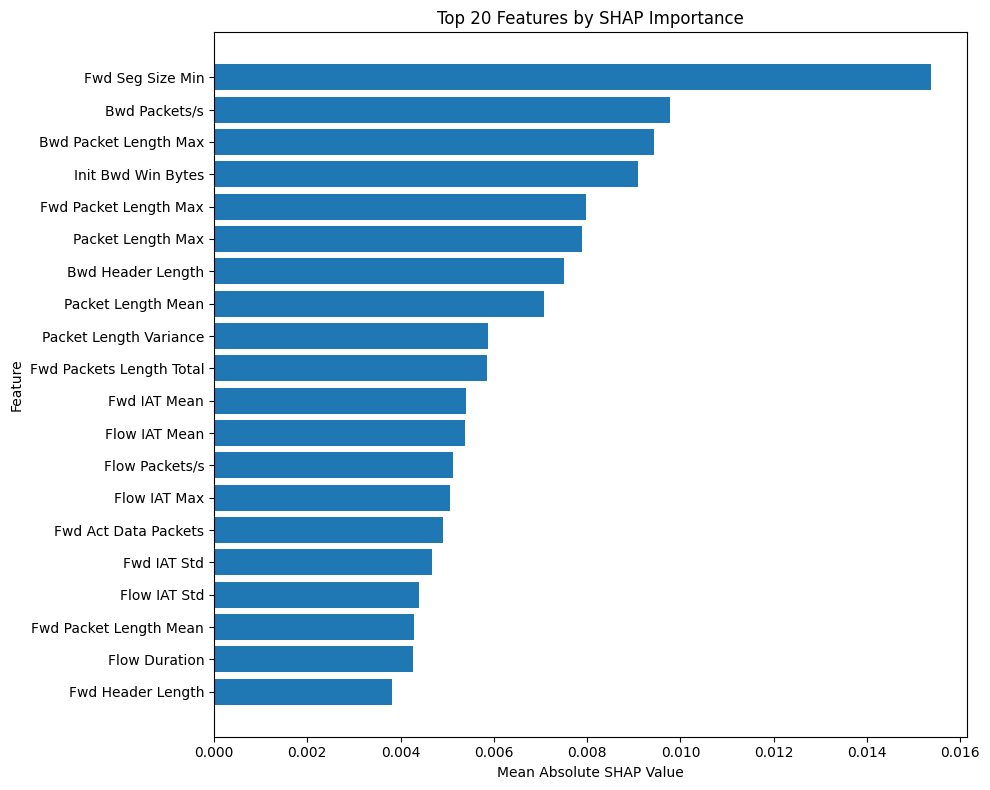

In [19]:
plt.figure(figsize=(10, 8))

top_shap = shap_results.head(20)

plt.barh(
    top_shap["Feature"][::-1],
    top_shap["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features by SHAP Importance")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
final_features = shap_results[
    shap_results["Feature"].isin(
        boruta_features
    )
]["Feature"].tolist()

print(
    "Final selected features:",
    len(final_features)
)

print("\nFinal feature list:")
print(final_features)

Final selected features: 43

Final feature list:
['Fwd Seg Size Min', 'Bwd Packets/s', 'Bwd Packet Length Max', 'Init Bwd Win Bytes', 'Fwd Packet Length Max', 'Packet Length Max', 'Bwd Header Length', 'Packet Length Mean', 'Packet Length Variance', 'Fwd Packets Length Total', 'Fwd IAT Mean', 'Flow IAT Mean', 'Flow Packets/s', 'Flow IAT Max', 'Fwd Act Data Packets', 'Fwd IAT Std', 'Flow IAT Std', 'Fwd Packet Length Mean', 'Flow Duration', 'Fwd Header Length', 'Init Fwd Win Bytes', 'Total Fwd Packets', 'Bwd IAT Total', 'Flow Bytes/s', 'Bwd IAT Min', 'Bwd IAT Mean', 'PSH Flag Count', 'Active Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd IAT Min', 'Active Mean', 'Bwd Packet Length Min', 'ACK Flag Count', 'Packet Length Min', 'Flow IAT Min', 'Active Max', 'Fwd Packet Length Min', 'Fwd PSH Flags', 'Protocol', 'URG Flag Count', 'Down/Up Ratio', 'Idle Std']


In [21]:
selected_features_df = pd.DataFrame({
    "Feature": final_features
})

selected_features_df.to_csv(
    "/kaggle/working/selected_features.csv",
    index=False
)

print("Selected feature list saved.")

Selected feature list saved.


In [22]:
X_train_selected = X_train[
    final_features
].copy()

X_test_selected = X_test[
    final_features
].copy()

print("Original X_train:", X_train.shape)
print("Selected X_train:", X_train_selected.shape)

print("Original X_test :", X_test.shape)
print("Selected X_test :", X_test_selected.shape)

Original X_train: (1785379, 77)
Selected X_train: (1785379, 43)
Original X_test : (446345, 77)
Selected X_test : (446345, 43)


In [23]:
X_train_selected.to_parquet(
    "/kaggle/working/X_train_selected.parquet",
    index=False
)

X_test_selected.to_parquet(
    "/kaggle/working/X_test_selected.parquet",
    index=False
)

print("Selected datasets saved.")

Selected datasets saved.


In [24]:
y_train.to_frame().to_parquet(
    "/kaggle/working/y_train_selected.parquet",
    index=False
)

y_test.to_frame().to_parquet(
    "/kaggle/working/y_test_selected.parquet",
    index=False
)

print("Labels saved.")

Labels saved.
